# 04 — Grad-CAM Analysis

Grad-CAM (Gradient-weighted Class Activation Mapping) highlights which **frequency regions and time segments** the model focuses on when classifying each emotion.

- **Red/yellow areas** = high importance (model relies on these)
- **Blue areas** = low importance
- Target layer: `conv4` — the last convolutional layer

To regenerate all figures:
```bash
# CREMA-D — clean, all emotions
python grad_cam.py --feature mel
python grad_cam.py --feature mfcc

# CREMA-D — clean vs noisy (SNR-5 dB)
python grad_cam.py --feature mel --snr 5

# RAVDESS — from scratch
python grad_cam.py --feature mel --dataset ravdess

# RAVDESS — transfer model
python grad_cam.py --feature mel --dataset ravdess --pretrain-from models/mel_best_model.pt --lr 0.0001
```

In [1]:
import sys
sys.path.insert(0, '..')

import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

EMOTIONS = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad']

## Mel-CNN — Grad-CAM per Emotion

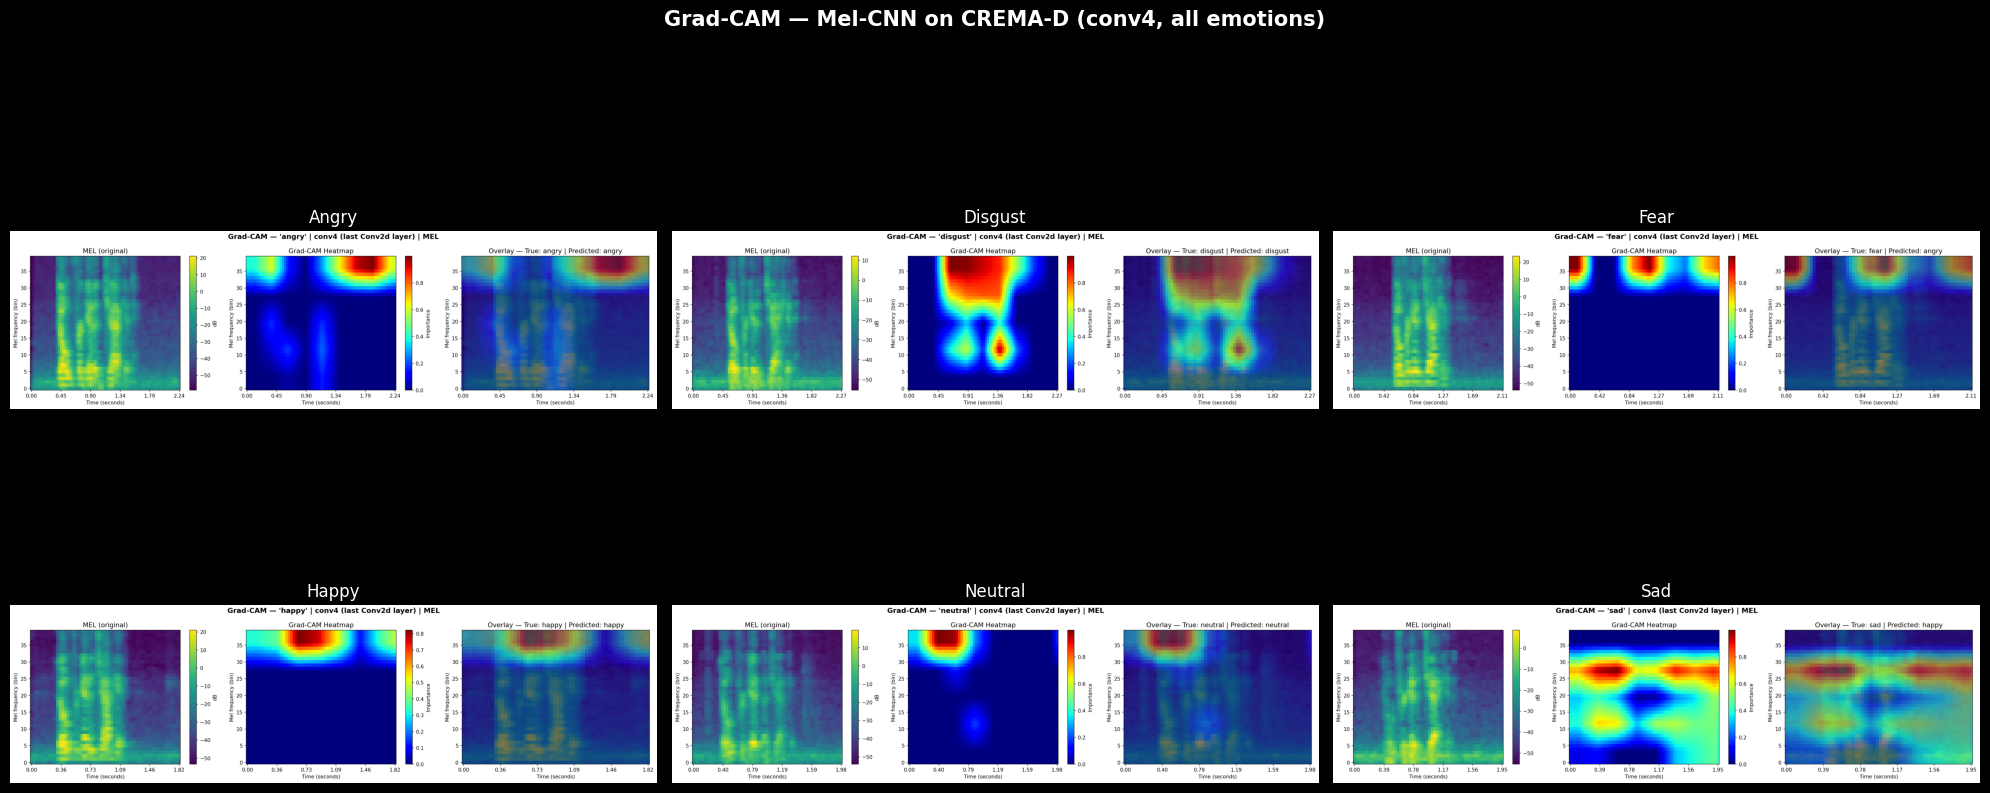

In [2]:
CREMA_EMOTIONS = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad']

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for ax, emotion in zip(axes, CREMA_EMOTIONS):
    path = f'../results/mel/gradcam/gradcam_{emotion}.png'
    if os.path.exists(path):
        ax.imshow(mpimg.imread(path))
        ax.set_title(emotion.capitalize(), fontsize=12)
    else:
        ax.text(0.5, 0.5, f'Not found', ha='center', va='center', transform=ax.transAxes)
    ax.axis('off')

plt.suptitle('Grad-CAM — Mel-CNN on CREMA-D (conv4, all emotions)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## MFCC-CNN — Grad-CAM per Emotion

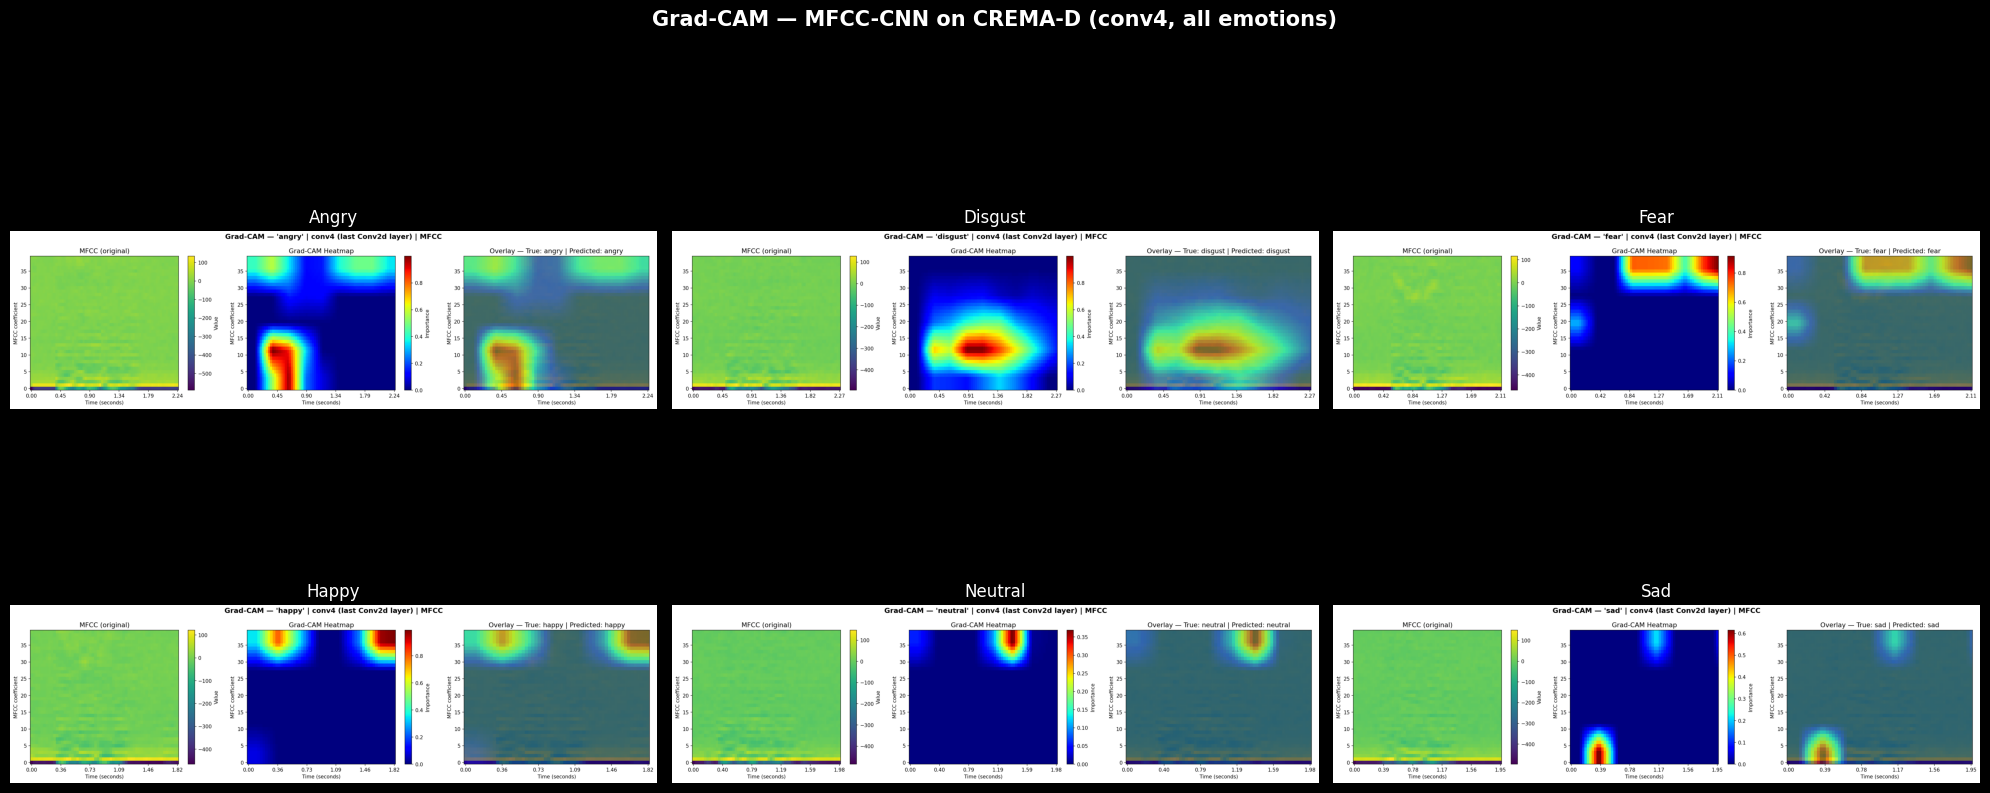

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for ax, emotion in zip(axes, CREMA_EMOTIONS):
    path = f'../results/mfcc/gradcam/gradcam_{emotion}.png'
    if os.path.exists(path):
        ax.imshow(mpimg.imread(path))
        ax.set_title(emotion.capitalize(), fontsize=12)
    else:
        ax.text(0.5, 0.5, f'Not found', ha='center', va='center', transform=ax.transAxes)
    ax.axis('off')

plt.suptitle('Grad-CAM — MFCC-CNN on CREMA-D (conv4, all emotions)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Interpretation Guide

Each Grad-CAM figure has 3 panels:
1. **Original feature** (mel or MFCC) — what the model received as input
2. **Grad-CAM heatmap** — activation importance map from conv4
3. **Overlay** — heatmap blended onto the feature for easy reading

**What to look for:**
- Does the model focus on **low or high frequencies**?
- Does it focus on the **beginning, middle, or end** of the utterance?
- Are there differences between emotions (e.g. angry vs neutral)?
- Are there differences between mel and MFCC models for the same emotion?

## Noise Robustness — Grad-CAM: Clean vs. SNR-5 dB

Each emotion shows a 2-row figure: clean input (top) vs. heavily noisy input at SNR-5 dB (bottom).
This shows whether the model's attention shifts or becomes more diffuse under noise.

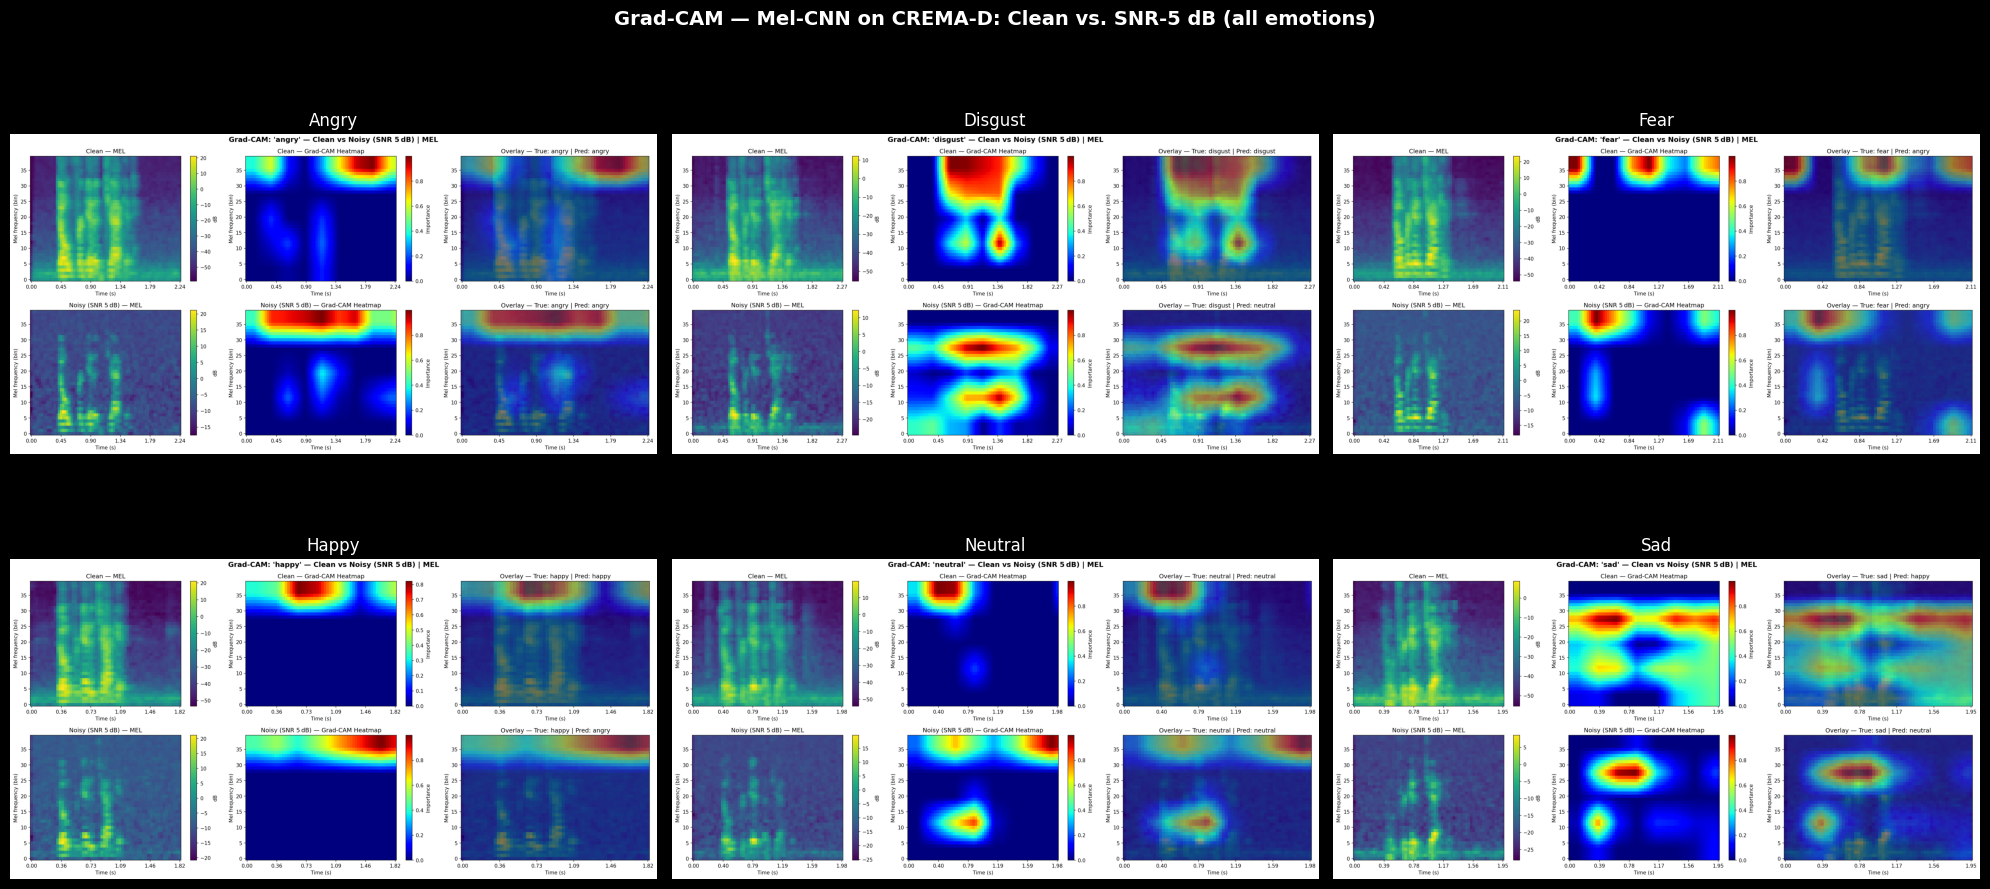

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for ax, emotion in zip(axes, CREMA_EMOTIONS):
    path = f'../results/mel/gradcam_snr5/gradcam_{emotion}_snr5.png'
    if os.path.exists(path):
        ax.imshow(mpimg.imread(path))
        ax.set_title(emotion.capitalize(), fontsize=12)
    else:
        ax.text(0.5, 0.5, f'Not found', ha='center', va='center', transform=ax.transAxes)
    ax.axis('off')

plt.suptitle('Grad-CAM — Mel-CNN on CREMA-D: Clean vs. SNR-5 dB (all emotions)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## RAVDESS — Grad-CAM: From Scratch vs. Transfer Learning

Comparing how the two RAVDESS models attend to the same audio.
- **Top row**: model trained from scratch on RAVDESS (38.14% macro F1)
- **Bottom row**: model fine-tuned from CREMA-D weights, lr=0.0001 (44.97% macro F1)

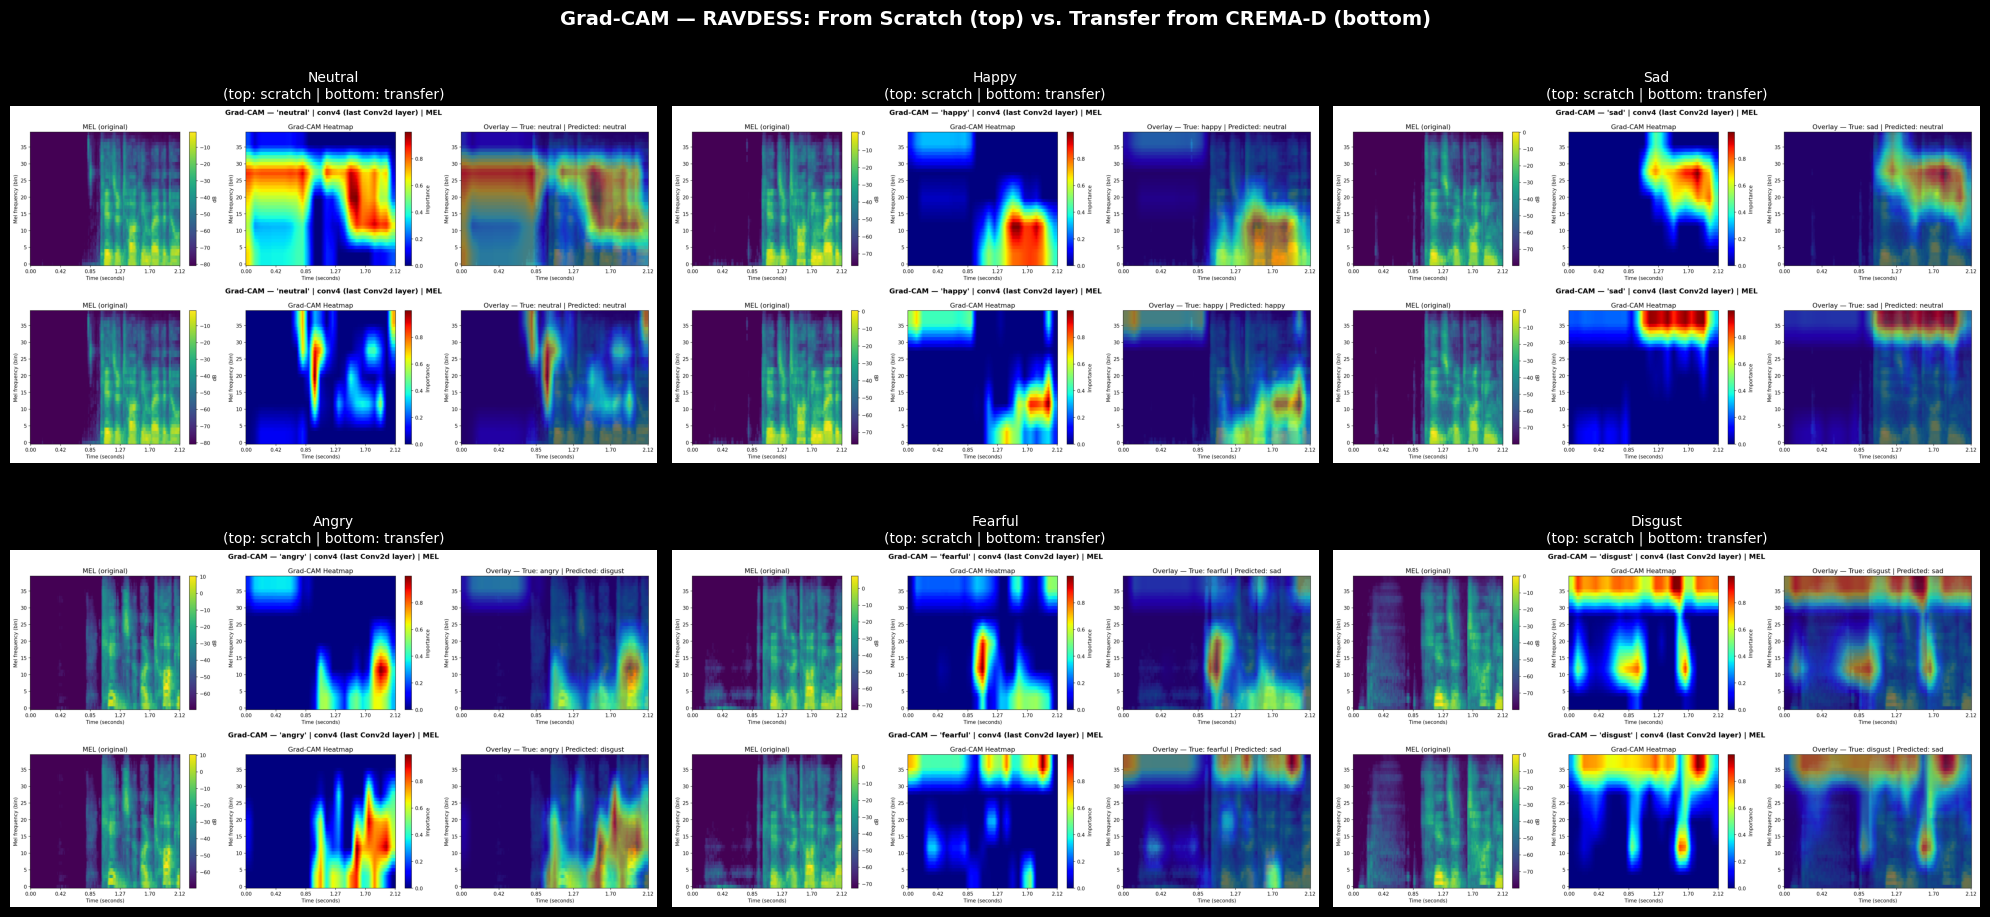

In [5]:
RAVDESS_EMOTIONS = ['neutral', 'happy', 'sad', 'angry', 'fearful', 'disgust']

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for ax, emotion in zip(axes, RAVDESS_EMOTIONS):
    # Show scratch vs transfer comparison side by side using the per-emotion gradcam files
    scratch_path   = f'../results/ravdess_mel/gradcam/gradcam_{emotion}.png'
    transfer_path  = f'../results/ravdess_mel_lr0003_transfer/gradcam/gradcam_{emotion}.png'

    # Stack scratch (top) and transfer (bottom) into one image
    if os.path.exists(scratch_path) and os.path.exists(transfer_path):
        import numpy as np
        img_s = plt.imread(scratch_path)
        img_t = plt.imread(transfer_path)
        # Resize to same width if needed
        h = min(img_s.shape[0], img_t.shape[0])
        w = min(img_s.shape[1], img_t.shape[1])
        stacked = np.vstack([img_s[:h, :w], img_t[:h, :w]])
        ax.imshow(stacked)
        ax.set_title(f'{emotion.capitalize()}\n(top: scratch | bottom: transfer)', fontsize=10)
    elif os.path.exists(scratch_path):
        ax.imshow(plt.imread(scratch_path))
        ax.set_title(f'{emotion.capitalize()} (scratch only)', fontsize=10)
    else:
        ax.text(0.5, 0.5, 'Not found', ha='center', va='center', transform=ax.transAxes)
    ax.axis('off')

plt.suptitle('Grad-CAM — RAVDESS: From Scratch (top) vs. Transfer from CREMA-D (bottom)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()